# LSTM Implementation #1 on Benchmark Products

This notebook evaluates the first LSTM implementation reused from the repository:

- `src.models.advanced_deep_forecast_models.LSTMForecastModel`

Scope:
- run the model on the 3 official benchmark products selected from the M5 GNN subset
- use the unified protocol defined for the GNN benchmark workstream
- export training summary, real-vs-prediction plots, metrics, and flat/non-flat conclusions

## Benchmark Products

- high-demand / stable: `FOODS_3_228_CA_1_validation`
- intermittent: `FOODS_2_044_CA_3_validation`
- low-volume: `HOBBIES_1_133_CA_4_validation`

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parent.parent
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loaders.load_m5 import load_m5_single_series
from src.experiments.common_protocol import OFFICIAL_BENCHMARK_PROTOCOL, split_series_protocol
from src.metrics.behavioral_metrics import behavioral_metrics
from src.models.advanced_deep_forecast_models import LSTMForecastModel

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(OFFICIAL_BENCHMARK_PROTOCOL.seed)

In [2]:
CONFIG = {
    'M5_BASE_PATH': ROOT / 'data' / 'raw' / 'm5',
    'BENCHMARK_PRODUCTS': [
        {
            'series_id': 'FOODS_3_228_CA_1_validation',
            'label': 'high_demand_stable',
        },
        {
            'series_id': 'FOODS_2_044_CA_3_validation',
            'label': 'intermittent',
        },
        {
            'series_id': 'HOBBIES_1_133_CA_4_validation',
            'label': 'low_volume',
        },
    ],
    'MAX_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.max_days,
    'CONTEXT_LENGTH': OFFICIAL_BENCHMARK_PROTOCOL.context_length,
    'VAL_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.val_days,
    'TEST_DAYS': OFFICIAL_BENCHMARK_PROTOCOL.test_days,
    'HIDDEN_SIZE': 64,
    'NUM_LAYERS': 2,
    'DROPOUT': 0.10,
    'EPOCHS': 30,
    'LR': 1e-3,
    'SEED': OFFICIAL_BENCHMARK_PROTOCOL.seed,
    'FLAT_VARIANCE_RATIO_THRESHOLD': 0.10,
    'OUTPUT_DIR': ROOT / 'reports' / 'gnn_benchmarks' / 'lstm_impl1_benchmark_products',
}

CONFIG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)
CONFIG

{'M5_BASE_PATH': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/data/raw/m5'),
 'BENCHMARK_PRODUCTS': [{'series_id': 'FOODS_3_228_CA_1_validation',
   'label': 'high_demand_stable'},
  {'series_id': 'FOODS_2_044_CA_3_validation', 'label': 'intermittent'},
  {'series_id': 'HOBBIES_1_133_CA_4_validation', 'label': 'low_volume'}],
 'MAX_DAYS': 365,
 'CONTEXT_LENGTH': 28,
 'VAL_DAYS': 28,
 'TEST_DAYS': 28,
 'HIDDEN_SIZE': 64,
 'NUM_LAYERS': 2,
 'DROPOUT': 0.1,
 'EPOCHS': 30,
 'LR': 0.001,
 'SEED': 42,
 'FLAT_VARIANCE_RATIO_THRESHOLD': 0.1,
 'OUTPUT_DIR': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/lstm_impl1_benchmark_products')}

In [3]:
def flat_nonflat_label(variance_ratio: float, threshold: float) -> str:
    return 'flat' if float(variance_ratio) < float(threshold) else 'non-flat'


def evaluate_one_product(product_cfg: dict) -> dict:
    series_id = product_cfg['series_id']
    label = product_cfg['label']

    df = load_m5_single_series(
        base_path=str(CONFIG['M5_BASE_PATH']),
        random_pick=False,
        series_id=series_id,
    )
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df = df.iloc[-CONFIG['MAX_DAYS']:].copy().reset_index(drop=True)

    y = df['sales'].to_numpy(dtype=float)
    y_train, y_val, y_test = split_series_protocol(
        y,
        val_days=CONFIG['VAL_DAYS'],
        test_days=CONFIG['TEST_DAYS'],
    )
    fit_history = np.concatenate([y_train, y_val])

    train_end = len(y_train)
    val_end = len(y_train) + len(y_val)
    train_df = df.iloc[:train_end].copy().reset_index(drop=True)
    val_df = df.iloc[train_end:val_end].copy().reset_index(drop=True)
    test_df = df.iloc[val_end:].copy().reset_index(drop=True)

    model = LSTMForecastModel(
        context_length=CONFIG['CONTEXT_LENGTH'],
        hidden_size=CONFIG['HIDDEN_SIZE'],
        num_layers=CONFIG['NUM_LAYERS'],
        dropout=CONFIG['DROPOUT'],
        epochs=CONFIG['EPOCHS'],
        lr=CONFIG['LR'],
        seed=CONFIG['SEED'],
    )
    model.fit(fit_history)
    y_pred, conf_low, conf_up = model.forecast(len(y_test), fit_history)

    beh = behavioral_metrics(y_test, y_pred)
    variance_ratio = float(beh['variance_ratio'])
    flat_label = flat_nonflat_label(variance_ratio, CONFIG['FLAT_VARIANCE_RATIO_THRESHOLD'])

    metrics_row = {
        'series_id': series_id,
        'benchmark_label': label,
        'model': 'LSTMForecastModel',
        'max_days': CONFIG['MAX_DAYS'],
        'train_days': int(len(y_train)),
        'val_days': int(len(y_val)),
        'fit_days': int(len(fit_history)),
        'test_days': int(len(y_test)),
        'context_length': CONFIG['CONTEXT_LENGTH'],
        'epochs': CONFIG['EPOCHS'],
        'hidden_size': CONFIG['HIDDEN_SIZE'],
        'num_layers': CONFIG['NUM_LAYERS'],
        'dropout': CONFIG['DROPOUT'],
        'lr': CONFIG['LR'],
        'final_loss': float(model.training_history_.get('final_loss', np.nan)),
        'zero_rate_fit': float(np.mean(fit_history == 0)),
        'zero_rate_test': float(np.mean(y_test == 0)),
        'mae': float(np.mean(np.abs(y_test - y_pred))),
        'rmse': float(np.sqrt(np.mean((y_test - y_pred) ** 2))),
        'pred_std': float(np.std(y_pred)),
        'real_std': float(np.std(y_test)),
        'variance_ratio': variance_ratio,
        'trend_correlation': float(beh['trend_correlation']),
        'direction_accuracy': float(beh['direction_accuracy']),
        'shape_similarity': float(beh['shape_similarity']),
        'peak_detection_rate': float(beh['peak_detection_rate']),
        'n_peaks_real': int(beh['n_peaks_real']),
        'n_peaks_detected': int(beh['n_peaks_detected']),
        'flat_nonflat': flat_label,
    }

    predictions_df = test_df[['date', 'sales']].copy()
    predictions_df['y_pred'] = y_pred
    predictions_df['conf_low'] = conf_low
    predictions_df['conf_up'] = conf_up
    predictions_df['series_id'] = series_id
    predictions_df['benchmark_label'] = label

    return {
        'series_id': series_id,
        'label': label,
        'raw_df': df,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'metrics_row': metrics_row,
        'predictions_df': predictions_df,
    }

In [4]:
runs = [evaluate_one_product(cfg) for cfg in CONFIG['BENCHMARK_PRODUCTS']]

training_summary_df = pd.DataFrame([
    {
        'series_id': run['series_id'],
        'benchmark_label': run['label'],
        'train_days': run['metrics_row']['train_days'],
        'val_days': run['metrics_row']['val_days'],
        'fit_days': run['metrics_row']['fit_days'],
        'test_days': run['metrics_row']['test_days'],
        'context_length': run['metrics_row']['context_length'],
        'epochs': run['metrics_row']['epochs'],
        'hidden_size': run['metrics_row']['hidden_size'],
        'num_layers': run['metrics_row']['num_layers'],
        'dropout': run['metrics_row']['dropout'],
        'lr': run['metrics_row']['lr'],
        'final_loss': run['metrics_row']['final_loss'],
    }
    for run in runs
])

metrics_df = pd.DataFrame([run['metrics_row'] for run in runs])
predictions_df = pd.concat([run['predictions_df'] for run in runs], ignore_index=True)

display(training_summary_df)
display(metrics_df)

,series_id,benchmark_label,train_days,val_days,fit_days,test_days,context_length,epochs,hidden_size,num_layers,dropout,lr,final_loss
0,FOODS_3_228_CA_1_validation,high_demand_stable,309,28,337,28,28,30,64,2,0.1000,0.0010,0.2284
1,FOODS_2_044_CA_3_validation,intermittent,309,28,337,28,28,30,64,2,0.1000,0.0010,0.3996
2,HOBBIES_1_133_CA_4_validation,low_volume,309,28,337,28,28,30,64,2,0.1000,0.0010,0.0482


,series_id,benchmark_label,model,max_days,train_days,val_days,fit_days,test_days,context_length,epochs,hidden_size,num_layers,dropout,lr,final_loss,zero_rate_fit,zero_rate_test,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,n_peaks_real,n_peaks_detected,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,LSTMForecastModel,365,309,28,337,28,28,30,64,2,0.1000,0.0010,0.2284,0.0119,0.0000,2.3173,2.8306,0.2505,2.7818,0.0901,0.5934,0.5556,0.6274,0.0000,8,0,flat
1,FOODS_2_044_CA_3_validation,intermittent,LSTMForecastModel,365,309,28,337,28,28,30,64,2,0.1000,0.0010,0.3996,0.6172,0.5000,1.1404,1.4944,0.0612,1.4569,0.0420,0.3584,0.2593,0.6977,0.0000,5,0,flat
2,HOBBIES_1_133_CA_4_validation,low_volume,LSTMForecastModel,365,309,28,337,28,28,30,64,2,0.1000,0.0010,0.0482,0.9436,1.0000,0.0397,0.0399,0.0038,0.0000,0.0000,NaN,0.0000,0.4444,1.0000,0,0,flat


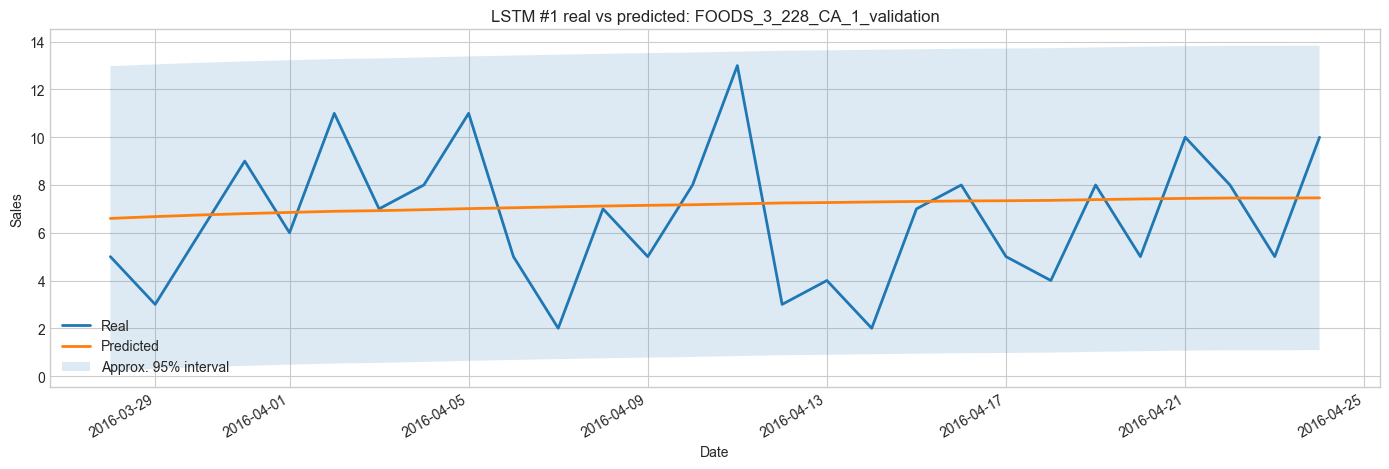

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\figures\high_demand_stable_FOODS_3_228_CA_1_validation_real_vs_predicted.png


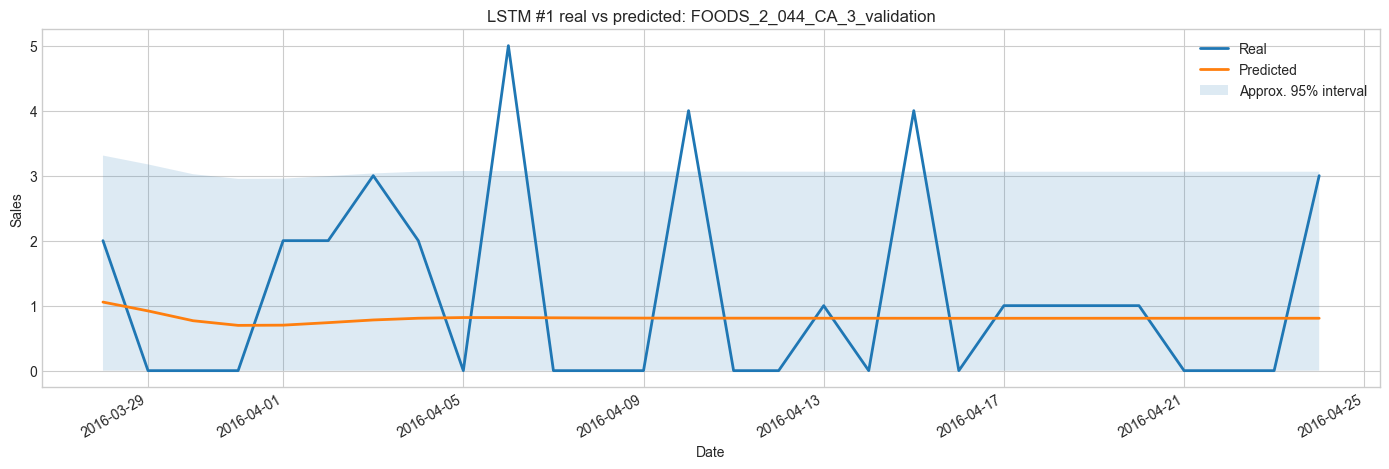

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\figures\intermittent_FOODS_2_044_CA_3_validation_real_vs_predicted.png


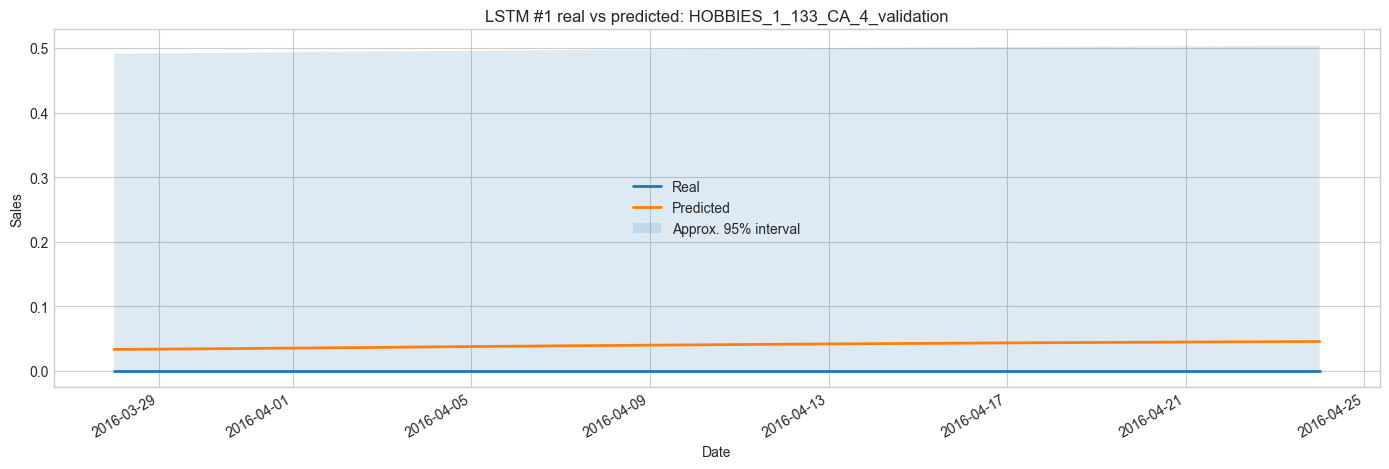

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\figures\low_volume_HOBBIES_1_133_CA_4_validation_real_vs_predicted.png


In [5]:
plot_dir = CONFIG['OUTPUT_DIR'] / 'figures'
plot_dir.mkdir(parents=True, exist_ok=True)

for run in runs:
    plot_df = run['predictions_df']
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.plot(plot_df['date'], plot_df['sales'], label='Real', linewidth=2)
    ax.plot(plot_df['date'], plot_df['y_pred'], label='Predicted', linewidth=2)
    ax.fill_between(plot_df['date'], plot_df['conf_low'], plot_df['conf_up'], alpha=0.15, label='Approx. 95% interval')
    ax.set_title(f"LSTM #1 real vs predicted: {run['series_id']}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plot_path = plot_dir / f"{run['label']}_{run['series_id']}_real_vs_predicted.png"
    fig.savefig(plot_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

In [6]:
conclusion_df = metrics_df[
    [
        'series_id',
        'benchmark_label',
        'mae',
        'rmse',
        'variance_ratio',
        'peak_detection_rate',
        'shape_similarity',
        'flat_nonflat',
    ]
].copy()

display(conclusion_df)

,series_id,benchmark_label,mae,rmse,variance_ratio,peak_detection_rate,shape_similarity,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,2.3173,2.8306,0.0901,0.0000,0.6274,flat
1,FOODS_2_044_CA_3_validation,intermittent,1.1404,1.4944,0.0420,0.0000,0.6977,flat
2,HOBBIES_1_133_CA_4_validation,low_volume,0.0397,0.0399,0.0000,1.0000,0.4444,flat


In [7]:
training_summary_path = CONFIG['OUTPUT_DIR'] / 'training_summary.csv'
metrics_path = CONFIG['OUTPUT_DIR'] / 'metrics.csv'
predictions_path = CONFIG['OUTPUT_DIR'] / 'predictions.csv'
conclusion_path = CONFIG['OUTPUT_DIR'] / 'flat_nonflat_conclusion.csv'

training_summary_df.to_csv(training_summary_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
conclusion_df.to_csv(conclusion_path, index=False)

print(f'Saved: {training_summary_path}')
print(f'Saved: {metrics_path}')
print(f'Saved: {predictions_path}')
print(f'Saved: {conclusion_path}')

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\training_summary.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\metrics.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\predictions.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\lstm_impl1_benchmark_products\flat_nonflat_conclusion.csv


## Interpretation Notes

- `flat_nonflat = flat` means the forecast variance is very small relative to the real test variance.
- The current threshold follows the practical heuristic reused from `notebook30`:
  - `variance_ratio < 0.10` -> `flat`
  - otherwise -> `non-flat`
- This notebook uses the unified GNN benchmark protocol rather than the older `365`-day test split used in the original Notebook 30.